In [315]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.datasets import make_regression

### Cost function for 1 Feature J(w) = wx
 
### **y=ax+b** , b = 0
### **y= ax**
---
#### Jw(x) = 1/2m * SUM(w*x1 - yi)^2

#### Depending on the slope, w we calculate the J(w) and try to minimize it.
#### Simple visualisation:

### **1)** f(x) for different slope coeff:

X - trening set
Y - prediction set (perfect linear relationship)
W = slope

In [ ]:
x = np.linspace(1,10,10)
w = np.linspace(0,5,50)
y = 2 * x

In [ ]:
class ModelReg():
    def __init__(self,X,y,w):
        self.y = y
        self.X=X
        self.w=w
    def getCost(self):
        cost_storage=[]
        for i,w1 in enumerate(w):
            cost_value = (1/2*len(self.X))*sum(w1*self.X-self.y)**2
            cost_storage.append(cost_value)
        return cost_storage
    def plotLine(self):
        for w1 in self.w:
            y_pred = w1 * self.X + np.random.uniform(0,2,1)
            plt.plot(self.X,y_pred)
        plt.title('Effect of slope on the regression line')
        plt.show()
    
    def plotCost(self):
        cost_values = self.getCost()
        # plotting the function J(w) in the function of w

        plt.plot(self.w,list(cost_values))
        plt.title("Cost function for each w coefficient")
        plt.scatter(x=2,y=75,marker='x',color='red',label='Minimum of the cost function')
        plt.legend()
        plt.show()

In [ ]:
inst = ModelReg(X=x,y=y,w=w)
inst.getCost()
inst.plotLine()
inst.plotCost()

### The **x** spot indicates the lowest value of  **slope (w)** of the J cost function

### Choosing that value **w** minimizes the cost function which in this case is __MSE__

### It is telling us the average squarred error between ground truth and predicted data

---
## **3D visualisation**
### **Contour plot** and **Surface plot**
#### y = b0 + b1x1 + error
#### $J(w, b) = \frac{1}{2m} \sum_{i=1}^m (f_{w,b}(x^{(i)}) - y^{(i)})^2$

#### I will try to implement NumPy's meshgrid and broadcast the array into 3D. 

#### Following the official NumPy documentation on __Broadcasting__:

##### 1) When operating on two arrays, NumPy compares their shapes element-wise. It starts with the trailing (i.e. rightmost) dimension and works its way left.

##### - they are equal, or
##### - one of them is 1.

If i write coeff. W as a grid of values with shape [50,50] and B0 as a grid of values in shape[50,50] then
W is not scalar anymore but matrix 50x50 (m*n)

      
     W[j,k]⋅xi​

Shape of X is (50,)

In order to make (50,50,m), I need to change the shape of X from (50,) to (1,1,m) - > 3 axes __tensor__

In [337]:
class test3():
    def __init__(self):
        self.x = np.linspace(1,5,50)
        self.y = 2 * self.x + 2
        self.w_range = np.linspace(0,4,50)
        self.b_range = np.linspace(0,4,50)
    def broadcast(self):
        self.W,self.B = np.meshgrid(self.w_range,self.b_range) # W = [50,50] , B = [50,50]
        self.reshape_x = self.x.reshape(1,1,-1)
        self.reshape_y = self.y.reshape(1,1,-1)
        self.reshape_w = self.W[:,:,None]
        self.reshape_b = self.B[:,:,None]
    def calculate_vectorized(self):
        self.resid = self.reshape_w*self.reshape_x+self.reshape_b - self.reshape_y
        m = len(self.reshape_x)
        cost = (1/(2*m))*np.sum((self.resid)**2,axis=2)
        return cost
    def plot_contour(self):
        fig = plt.figure(figsize=(12,8))
        plt.contour(self.W,self.B,self.calculate_vectorized(),cmap='plasma')
        plt.axis('scaled')
        plt.show()
    def plot_3D(self):
        fig = plt.figure()
        ax = plt.axes(projection='3d')
        ax.plot_surface(self.W,self.B,self.calculate_vectorized(),cmap='plasma',linewidth=0)
        ax.view_init(30,60)
        plt.show()


#### Axis = 2 because i want to close the dimension on the data not on the parameters.

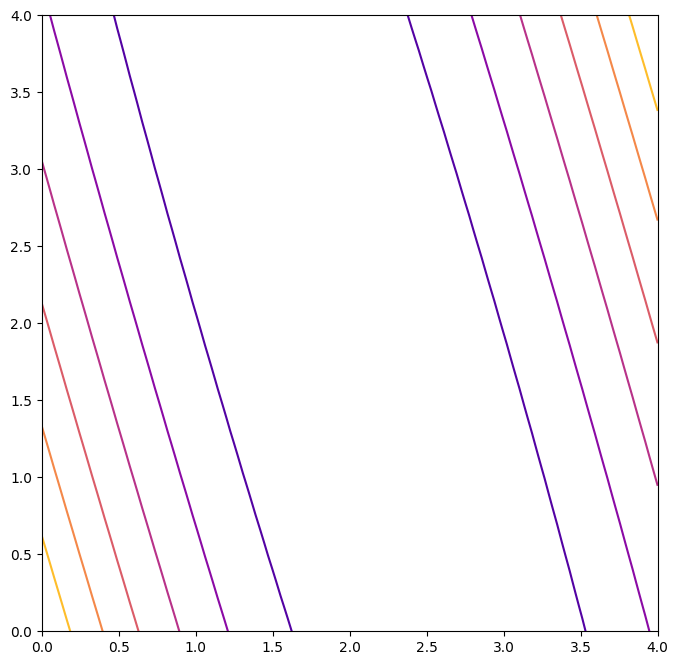

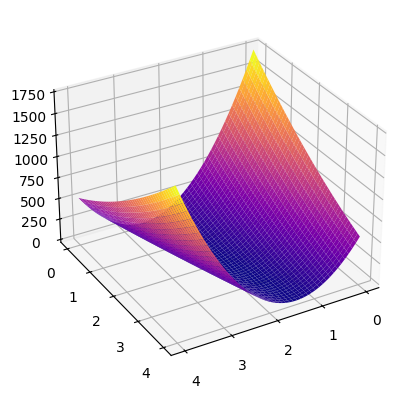

In [338]:
t = test3()
t.broadcast()
cost = t.calculate_vectorized()
t.plot_contour()
t.plot_3D()